<a href="https://colab.research.google.com/github/eman-cmd/NextGen-Retail-Banking-Intelligence/blob/main/Multi_Touch_Marketing_Campaign_Attribution_And_ROI_Optimization_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
file_name = "multi_touch_attribution_data.csv"
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\n--- Available Columns ---")
print(df.columns.tolist())
print("\n--- First 3 Rows ---")
df.head(3)

Dataset loaded successfully!
Shape: (10000, 5)

--- Available Columns ---
['User ID', 'Timestamp', 'Channel', 'Campaign', 'Conversion']

--- First 3 Rows ---


,User ID,Timestamp,Channel,Campaign,Conversion
0,83281,2025-02-10 07:58:51,Email,New Product Launch,No
1,68071,2025-02-10 23:38:48,Search Ads,Winter Sale,No
2,90131,2025-02-11 10:41:07,Social Media,Brand Awareness,Yes


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Clean Column Names to snake_case
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

# 2. Convert Data Types
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['conversion'] = df['conversion'].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

# 3. Sort chronologically by user journey path
df = df.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)

# 4. Filter only for users who eventually converted to track their path to purchase
converting_users = df[df['conversion'] == 1]['user_id'].unique()
df_converted = df[df['user_id'].isin(converting_users)].copy()

# 5. Assign relative touchpoint index positions per user journey
df_converted['touch_position'] = df_converted.groupby('user_id').cumcount() + 1
df_converted['total_touches'] = df_converted.groupby('user_id')['user_id'].transform('count')

print("Data preprocessing complete!")
print(f"Total entries from converting paths: {df_converted.shape[0]}")
print(f"Unique successful buyers tracked: {len(converting_users)}")


Data preprocessing complete!
Total entries from converting paths: 9006
Unique successful buyers tracked: 2381


In [ ]:
# 1. Extract First-Touch Channel for each buyer
first_touch = df_converted[df_converted['touch_position'] == 1].copy()
first_attribution = first_touch.groupby('channel')['conversion'].sum().reset_index()
first_attribution.columns = ['channel', 'first_touch_conversions']

# 2. Extract Last-Touch Channel for each buyer
last_touch = df_converted[df_converted['touch_position'] == df_converted['total_touches']].copy()
last_attribution = last_touch.groupby('channel')['conversion'].sum().reset_index()
last_attribution.columns = ['channel', 'last_touch_conversions']

# 3. Merge Attribution Models for comparison
attribution_summary = pd.merge(first_attribution, last_attribution, on='channel', how='outer').fillna(0)

print("--- HEURISTIC ATTRIBUTION BREAKDOWN ---")
print(attribution_summary.to_string(index=False))


--- HEURISTIC ATTRIBUTION BREAKDOWN ---
       channel  first_touch_conversions  last_touch_conversions
Direct Traffic                      248                     236
   Display Ads                      254                     238
         Email                      221                     235
      Referral                      235                     250
    Search Ads                      211                     230
  Social Media                      234                     221


In [ ]:
# 1. Calculate linear credit weight per touchpoint entry
df_converted['linear_credit'] = 1.0 / df_converted['total_touches']

# 2. Sum up linear credits across channels
linear_attribution = df_converted.groupby('channel')['linear_credit'].sum().reset_index()
linear_attribution.columns = ['channel', 'linear_conversions']

# 3. Merge into the main attribution summary framework
attribution_summary = pd.merge(attribution_summary, linear_attribution, on='channel', how='outer').fillna(0)

print("--- REVENUE ATTRIBUTION COMPARISON DASHBOARD ---")
print(attribution_summary.round(1).to_string(index=False))


--- REVENUE ATTRIBUTION COMPARISON DASHBOARD ---
       channel  first_touch_conversions  last_touch_conversions  linear_conversions
Direct Traffic                      248                     236               408.3
   Display Ads                      254                     238               407.2
         Email                      221                     235               387.7
      Referral                      235                     250               398.7
    Search Ads                      211                     230               381.5
  Social Media                      234                     221               397.6


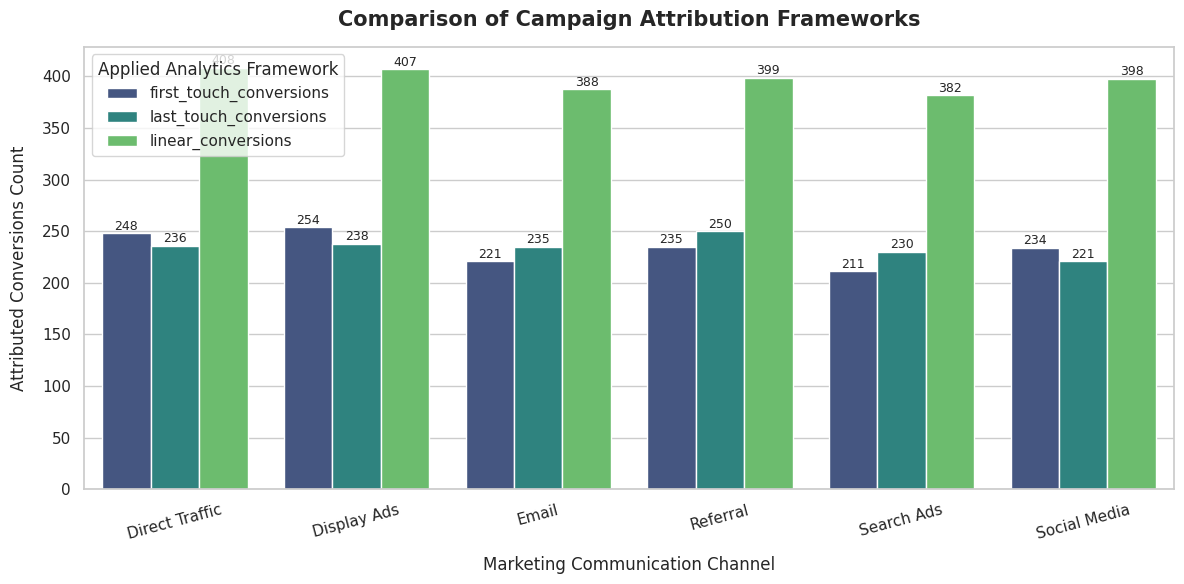

In [ ]:
import seaborn as sns

# Set up clean canvas styling
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Restructure the dataset for clear plotting with seaborn
melted_summary = attribution_summary.melt(id_vars='channel',
                                          var_name='Attribution Model',
                                          value_name='Attribution Score')

# Generate the grouped bar plot
ax = sns.barplot(x='channel', y='Attribution Score', hue='Attribution Model', data=melted_summary, palette='viridis')

# Add context annotations and styling elements
plt.title('Comparison of Campaign Attribution Frameworks', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Marketing Communication Channel', fontsize=12, labelpad=10)
plt.ylabel('Attributed Conversions Count', fontsize=12, labelpad=10)
plt.xticks(rotation=15)
plt.legend(title='Applied Analytics Framework')

# Display precise data counts above the bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.0f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5),
                    textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()
